# Задание

In [102]:
# ДЗ 4
# 1. Подберите параметры алгоритма разрастания регионов так, чтобы был выделен весь участок газона.
# 2. Реализуйте вычисление критерия однородности, отличного от представленного. Сравните результаты.
# 3. Применить алгоритм сегментации watershed + distance_transform для задачи подсчета пальмовых деревьев.

# 1. Подберите параметры алгоритма разрастания регионов так, чтобы был выделен весь участок газона.

In [103]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import math

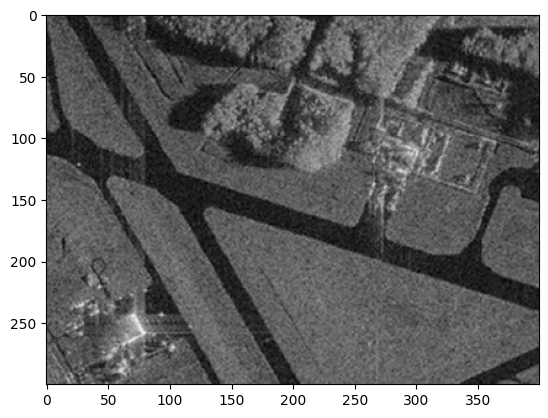

In [104]:
image = cv2.imread('sar_1.jpg')
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
plt.imshow(image_gray, cmap="gray")
plt.show()

In [105]:
def homo_average(img, mask, point, T):
    av_val = img[mask > 0].sum() / np.count_nonzero(img[mask > 0])
                                                            
    if abs(av_val - img[point]) <= T:
        return True
    
    return False

def region_growing(image, seed_point,homo_fun,r, T):
    mask = np.zeros(image_gray.shape, np.uint8)
    mask[seed_point] = 1
    count = 1
    while count > 0:
        count = 0
        local_mask = np.zeros(image_gray.shape, np.uint8)
        for i in range(r,image.shape[0] - r):
            for j in range(r,image.shape[1] - r):
                if mask[i,j]==0 and mask[i - r:i + r, j-r: j+r].sum() > 0:
                    if homo_fun(image, mask, (i,j), T):
                        local_mask[i,j] = 1
        count = np.count_nonzero(local_mask)
        mask += local_mask
        
    return mask*255

In [106]:
images = {"Original": image_gray}

seed_point = (250,250)
r = 4
t = 20

mask = region_growing(image_gray, seed_point, homo_average, r, t)
images[f"Mask: R={r}, T={20}"] = mask

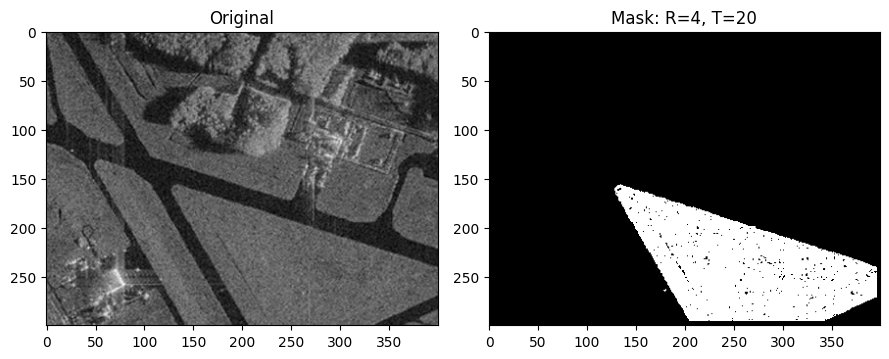

In [107]:
# Show images
fig, axs = plt.subplots(1, 2, figsize=(9, 5))

col = 0
for col, (key, img) in enumerate(images.items()):
    axs[col].imshow(img, cmap='gray')
    axs[col].set_title(key)

plt.tight_layout()
plt.show()

# 2. Реализуйте вычисление критерия однородности, отличного от представленного. Сравните результаты.

In [108]:
z = np.float32(image_gray.reshape((-1,3)))

K = 3
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 10, 1.0) 

ret, label, center = cv2.kmeans(z, K, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)

# Restore image
center = np.uint8(center)
res = center[label.flatten()]
res = res.reshape((image_gray.shape))
images[f"Kmeans (K={K})"] = res

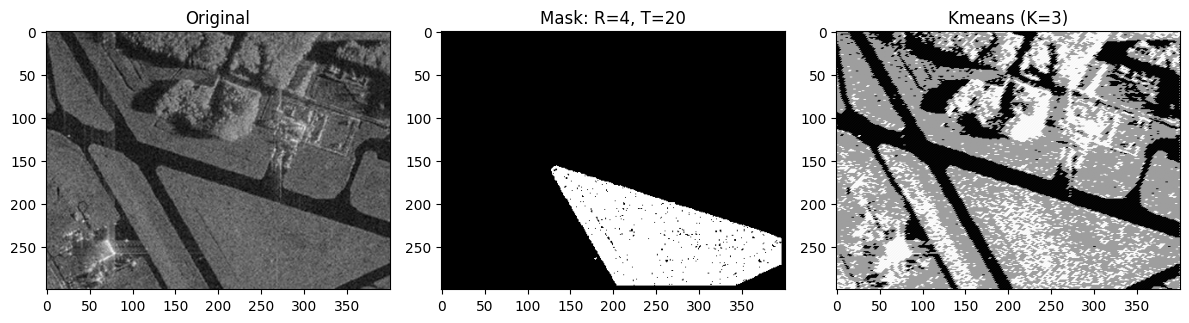

In [109]:
# Show images
fig, axs = plt.subplots(1, 3, figsize=(12, 5))

col = 0
for col, (key, img) in enumerate(images.items()):
    axs[col].imshow(img, cmap='gray')
    axs[col].set_title(key)

plt.tight_layout()
plt.show()

# 3. Применить алгоритм сегментации watershed + distance_transform для задачи подсчета пальмовых деревьев.

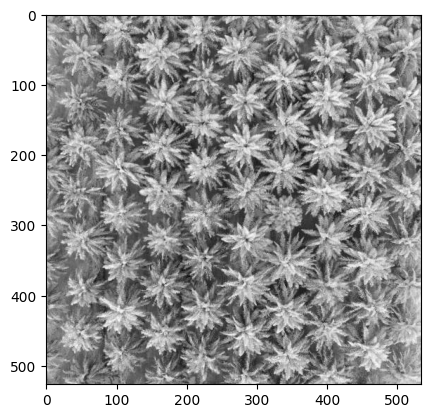

In [110]:
palm = cv2.imread("palm_1.JPG")
palm_gray = cv2.cvtColor(palm, cv2.COLOR_BGR2GRAY)
plt.imshow(palm_gray, cmap="gray")
plt.show()

In [111]:
# GaussianBlur
palm_gb = cv2.GaussianBlur(palm_gray, (11, 11), 0)
ret, thresh = cv2.threshold(palm_gb, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU) 

# DistanceTransform
dist = cv2.distanceTransform(thresh, cv2.DIST_L2, 5) 
ret, sure_fg = cv2.threshold(dist, 0.58 * dist.max(), 255, cv2.THRESH_BINARY) 
sure_fg = sure_fg.astype(np.uint8)

# Count palms
ret, mark = cv2.connectedComponents(sure_fg)
mark = cv2.watershed(palm, mark.astype(np.int32))
count = len(np.unique(mark)) - 1

Palm count:  97


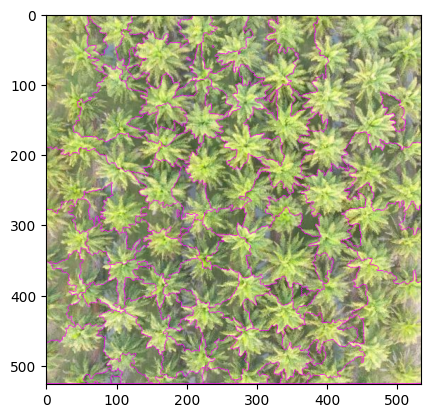

In [112]:
palm_res = palm.copy()
palm_res[mark == -1] = [255, 0, 255]

plt.imshow(cv2.cvtColor(palm_res, cv2.COLOR_BGR2RGB))
print("Palm count: ", count)